In [12]:
from pathlib import Path
import nibabel as nib
import matplotlib.pyplot as plt

In [5]:
# Set the project root to the parent of the current working directory
PROJECT_ROOT = Path.cwd().parent

# Create the path to the raw dataset folder
DATA_DIR = PROJECT_ROOT / "data" / "raw"


# Find all NIfTI MRI files in the raw dataset
nifti_files = [
    file
    for file in DATA_DIR.rglob("*")
    if file.name.lower().endswith((".nii", ".nii.gz"))
]

# Display the total number of NIfTI files found
print(f"NIfTI files found: {len(nifti_files)}")


# Display the first 10 NIfTI files
for file in nifti_files[:10]:
    print(file.relative_to(DATA_DIR))

NIfTI files found: 688
mri_datscan_ppmi/datscan b.tech/control/PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011135001960_1_S131286_I339559.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_3270_NM_Reconstructed_DaTSCAN_Br_20121018134659840_1_S124326_I341074.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_139138_NM_Reconstructed_DaTSCAN_Br_20220428101444617_1_S1128612_I1574634.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_121621_NM_Reconstructed_DaTSCAN_Br_20220110100814312_1_S1094231_I1531391.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_3857_NM_Reconstructed_DaTSCAN_Br_20121002162142065_1_S127580_I337837.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_3966_NM_Reconstructed_DaTSCAN_Br_20130909140447954_1_S191678_I388574.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_118726_NM_Reconstructed_DaTSCAN_Br_20220103151010900_1_S1092680_I1529627.nii
mri_datscan_ppmi/

In [9]:
# Check that at least one NIfTI file was found
if nifti_files:

    # Select the first NIfTI file in the list
    example_file = nifti_files[0]

    # Display the file being loaded
    print("\nLoading:")
    print(example_file)

    # Load the MRI scan using nibabel
    image = nib.load(example_file)

    # Display the dimensions of the MRI volume
    print("\nMRI shape:")
    print(image.shape)

    # Display the data type used to store the MRI values
    print("\nData type:")
    print(image.get_data_dtype())


Loading:
/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/raw/mri_datscan_ppmi/datscan b.tech/control/PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345.nii

MRI shape:
(91, 109, 91)

Data type:
int16


In [11]:
# Convert the loaded MRI scan into a NumPy array
volume = image.get_fdata()

# Display the shape of the NumPy volume
print("\nNumPy volume shape:")
print(volume.shape)

# Display the minimum voxel intensity value
print("\nMinimum intensity:")
print(volume.min())

# Display the maximum voxel intensity value
print("\nMaximum intensity:")
print(volume.max())

# Display the average voxel intensity value
print("\nMean intensity:")
print(volume.mean())


NumPy volume shape:
(91, 109, 91)

Minimum intensity:
0.0

Maximum intensity:
32767.0

Mean intensity:
4365.211379204524


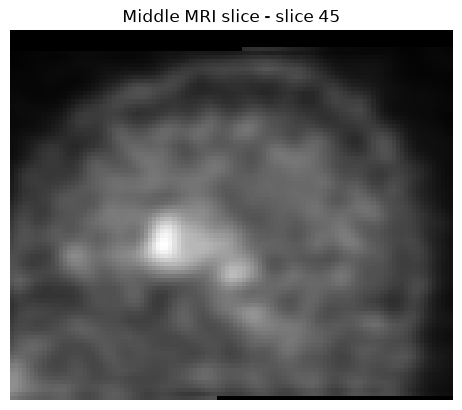

In [16]:
# Find the index of the middle slice along the third dimension
slice_number = volume.shape[2] // 2

# Extract the middle 2D slice from the 3D MRI volume
middle_slice = volume[:, :, slice_number]

# Display the MRI slice as a grayscale image
plt.imshow(middle_slice, cmap="gray")

# Add a title showing which slice is being displayed
plt.title(
    f"Middle MRI slice - slice {slice_number}"
)

# Hide the axis labels and tick marks
plt.axis("off")

# Display the image
plt.show()

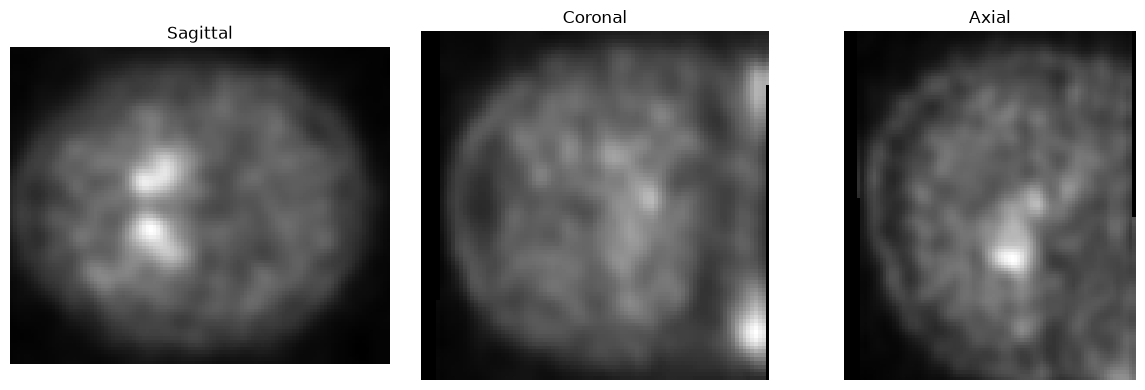

In [17]:
# Find the centre voxel position along each dimension of the MRI volume
x = volume.shape[0] // 2
y = volume.shape[1] // 2
z = volume.shape[2] // 2

# Create a figure containing three plots arranged side by side
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Display the middle sagittal slice
# Transpose (.T) rotates the image into the correct viewing orientation
axes[0].imshow(volume[x, :, :].T, cmap="gray", origin="lower")
axes[0].set_title("Sagittal")

# Display the middle coronal slice
axes[1].imshow(volume[:, y, :].T, cmap="gray", origin="lower")
axes[1].set_title("Coronal")

# Display the middle axial slice
axes[2].imshow(volume[:, :, z].T, cmap="gray", origin="lower")
axes[2].set_title("Axial")

# Remove the axes and tick marks from each MRI image
for ax in axes:
    ax.axis("off")

# Automatically adjust spacing between the three plots
plt.tight_layout()

# Display the figure
plt.show()

In [19]:
# Create a path for storing output figures generated by the project
OUTPUT_DIR = PROJECT_ROOT / "results" / "figures"

# Create the output directory if it does not already exist
OUTPUT_DIR.mkdir(
    parents=True,   # Also create any missing parent folders, such as "results"
    exist_ok=True   # Do not raise an error if the folder already exists
)

In [21]:
# Create the full file path for the saved MRI figure
output_file = OUTPUT_DIR / "example_mri_views.png"

# Save the current matplotlib figure as a high-resolution PNG image
plt.savefig(
    output_file,
    dpi=300,              # Save at 300 DPI for good report-quality resolution
    bbox_inches="tight"   # Remove unnecessary white space around the figure
)

# Display the location where the figure was saved
print(f"\nFigure saved to:\n{output_file}")


Figure saved to:
/Users/paulcollingwood/Documents/Source/parkinsons_ml/results/figures/example_mri_views.png


<Figure size 640x480 with 0 Axes>